# Group 23
Target Company - ***ITC***


**Vineeth Ulavala - 2022A7PS0071H**

**Pramukh Nandan Reddy Kallem - 2022A1PS0766H**

**Sri Jaitra Saketh Goparaju - 2022A7PS0183H**

**Sai Aditya kothamasu - 2022A7PS0076H**

**Rohan Verma Penumetcha - 2022A7PS2016H**

**Importing necessary libraries**

In [ ]:
!pip install yfinance
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

# **1) Calculate the cost of equity capital(Top down approach)**

**Download stock prices for the security monthly data last 5 years**

In [ ]:
itc_df = yf.download('ITC.NS',
                      start='2020-05-01',
                      end='2025-05-01',
                      progress=False,interval ='1mo'
)
itc_df.head()

Price,Close,High,Low,Open,Volume
Ticker,ITC.NS,ITC.NS,ITC.NS,ITC.NS,ITC.NS
Date,,,,,
2020-05-01,157.486008,158.004705,125.366364,145.276551,554395975
2020-06-01,155.331406,167.101959,144.199257,160.398734,764204539
2020-07-01,154.932404,166.383761,152.817699,155.331405,604197678
2020-08-01,160.339752,174.267739,159.416808,162.772951,567641852
2020-09-01,144.062454,162.143680,139.405803,160.339758,646294807


**Download Market index closing prices**

In [ ]:
nifty_df = yf.download('^NSEI', start='2020-05-01', end='2025-05-01')
print(nifty_df.head())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open  Volume
Ticker            ^NSEI        ^NSEI        ^NSEI        ^NSEI   ^NSEI
Date                                                                  
2020-05-04  9293.500000  9533.500000  9266.950195  9533.500000  687500
2020-05-05  9205.599609  9450.900391  9190.750000  9429.400391  725200
2020-05-06  9270.900391  9346.900391  9116.500000  9226.799805  722200
2020-05-07  9199.049805  9277.849609  9175.900391  9234.049805  708700
2020-05-08  9251.500000  9382.650391  9238.200195  9376.950195  609100


In [ ]:
nifty_df = yf.download('^NSEI',
                      start='2020-05-01',
                      end='2025-05-01',
                      progress=False,interval ='1mo',
)
nifty_df.head()

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2020-05-01,9580.299805,9598.849609,8806.750000,9533.500000,13675900
2020-06-01,10302.099609,10553.150391,9544.349609,9726.849609,16778800
2020-07-01,11073.450195,11341.400391,10299.599609,10323.799805,14640200
2020-08-01,11387.500000,11794.250000,10882.250000,11057.549805,14035500
2020-09-01,11247.549805,11618.099609,10790.200195,11464.299805,12928400


In [ ]:
print(nifty_df.columns)

MultiIndex([( 'Close', '^NSEI'),
            (  'High', '^NSEI'),
            (   'Low', '^NSEI'),
            (  'Open', '^NSEI'),
            ('Volume', '^NSEI')],
           names=['Price', 'Ticker'])


In [ ]:
#Calculate Log returns
nifty_df['Return_NIFTY'] = np.log(nifty_df['Close']/nifty_df['Close'].shift(1))
print(nifty_df['Return_NIFTY'])

Date
2020-05-01         NaN
2020-06-01    0.072639
2020-07-01    0.072203
2020-08-01    0.027966
2020-09-01   -0.012366
2020-10-01    0.034503
2020-11-01    0.107904
2020-12-01    0.075195
2021-01-01   -0.025142
2021-02-01    0.063546
2021-03-01    0.011058
2021-04-01   -0.004065
2021-05-01    0.063018
2021-06-01    0.008861
2021-07-01    0.002639
2021-08-01    0.083291
2021-09-01    0.027970
2021-10-01    0.003032
2021-11-01   -0.039737
2021-12-01    0.021601
2022-01-01   -0.000819
2022-02-01   -0.031992
2022-03-01    0.039169
2022-04-01   -0.020957
2022-05-01   -0.030756
2022-06-01   -0.049712
2022-07-01    0.083720
2022-08-01    0.034430
2022-09-01   -0.038161
2022-10-01    0.052301
2022-11-01    0.040590
2022-12-01   -0.035434
2023-01-01   -0.024781
2023-02-01   -0.020489
2023-03-01    0.003220
2023-04-01    0.039822
2023-05-01    0.025652
2023-06-01    0.034711
2023-07-01    0.029006
2023-08-01   -0.025637
2023-09-01    0.019773
2023-10-01   -0.028862
2023-11-01    0.053748
2023-1

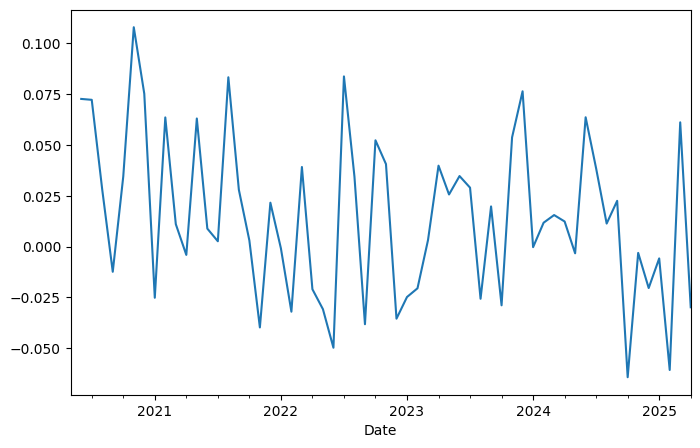

In [ ]:
nifty_df['Return_NIFTY'].plot(figsize=(8,5))
plt.show()

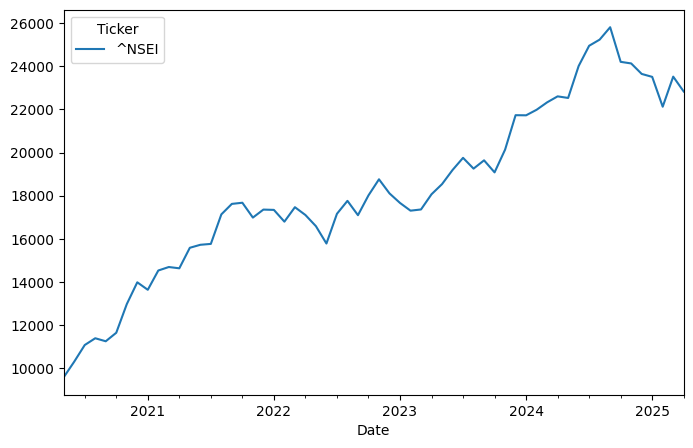

In [ ]:
nifty_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
nifty_df1 = nifty_df.dropna(axis=0)
nifty_df1.head()

Price,Close,High,Low,Open,Volume,Return_NIFTY
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,
Date,,,,,,
2020-06-01,10302.099609,10553.150391,9544.349609,9726.849609,16778800,0.072639
2020-07-01,11073.450195,11341.400391,10299.599609,10323.799805,14640200,0.072203
2020-08-01,11387.500000,11794.250000,10882.250000,11057.549805,14035500,0.027966
2020-09-01,11247.549805,11618.099609,10790.200195,11464.299805,12928400,-0.012366
2020-10-01,11642.400391,12025.450195,11347.049805,11364.450195,11602500,0.034503


In [ ]:
#Caclulate log returns
itc_df['Return_itc'] = np.log(itc_df['Close']/itc_df['Close'].shift(1))
print(itc_df['Return_itc'])

Date
2020-05-01         NaN
2020-06-01   -0.013776
2020-07-01   -0.002572
2020-08-01    0.034306
2020-09-01   -0.107048
2020-10-01   -0.038289
2020-11-01    0.158593
2020-12-01    0.076282
2021-01-01   -0.027897
2021-02-01    0.002948
2021-03-01    0.092827
2021-04-01   -0.075553
2021-05-01    0.066819
2021-06-01   -0.066325
2021-07-01    0.038471
2021-08-01    0.030513
2021-09-01    0.111188
2021-10-01   -0.056399
2021-11-01   -0.009227
2021-12-01   -0.014117
2022-01-01    0.009812
2022-02-01   -0.019952
2022-03-01    0.172318
2022-04-01    0.034892
2022-05-01    0.041877
2022-06-01    0.033661
2022-07-01    0.102596
2022-08-01    0.055985
2022-09-01    0.035855
2022-10-01    0.048475
2022-11-01   -0.025266
2022-12-01   -0.025167
2023-01-01    0.060846
2023-02-01    0.066824
2023-03-01    0.033538
2023-04-01    0.104043
2023-05-01    0.045815
2023-06-01    0.028744
2023-07-01    0.030745
2023-08-01   -0.057449
2023-09-01    0.010632
2023-10-01   -0.036668
2023-11-01    0.017126
2023-1

In [ ]:
itc_df1 = itc_df.dropna(axis=0)
itc_df1.head()

Price,Close,High,Low,Open,Volume,Return_itc
Ticker,ITC.NS,ITC.NS,ITC.NS,ITC.NS,ITC.NS,
Date,,,,,,
2020-06-01,155.331406,167.101959,144.199257,160.398734,764204539,-0.013776
2020-07-01,154.932404,166.383761,152.817699,155.331405,604197678,-0.002572
2020-08-01,160.339752,174.267739,159.416808,162.772951,567641852,0.034306
2020-09-01,144.062454,162.143680,139.405803,160.339758,646294807,-0.107048
2020-10-01,138.650650,146.999053,137.056487,146.411730,527572084,-0.038289


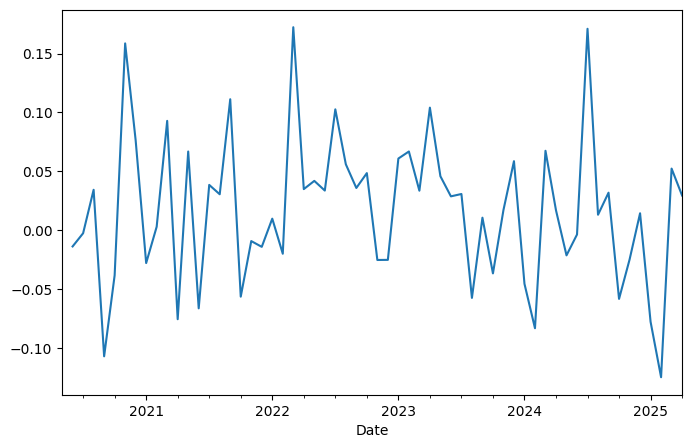

In [ ]:
itc_df['Return_itc'].plot(figsize=(8,5))
plt.show()

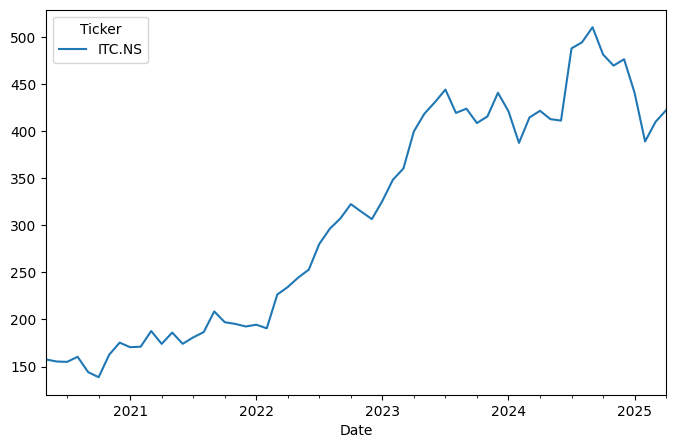

In [ ]:
itc_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
itc_df1_returns = itc_df1['Return_itc']
itc_df1_returns.head()

,Return_itc
Date,
2020-06-01,-0.013776
2020-07-01,-0.002572
2020-08-01,0.034306
2020-09-01,-0.107048
2020-10-01,-0.038289


In [ ]:
nifty_df1_returns = nifty_df1['Return_NIFTY']
nifty_df1_returns.head()

,Return_NIFTY
Date,
2020-06-01,0.072639
2020-07-01,0.072203
2020-08-01,0.027966
2020-09-01,-0.012366
2020-10-01,0.034503


In [ ]:
returns = pd.merge(nifty_df1_returns,itc_df1_returns,how='inner',on='Date')
returns.head()
returns.describe()

,Return_NIFTY,Return_itc
count,59.000000,59.000000
mean,0.014717,0.016706
std,0.040045,0.063042
min,-0.064221,-0.124791
25%,-0.020424,-0.025064
50%,0.011765,0.017126
75%,0.039495,0.050399
max,0.107904,0.172318


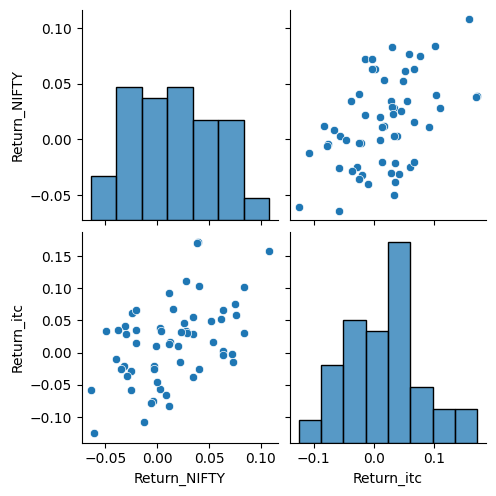

In [ ]:
sns.pairplot(returns)
plt.show()

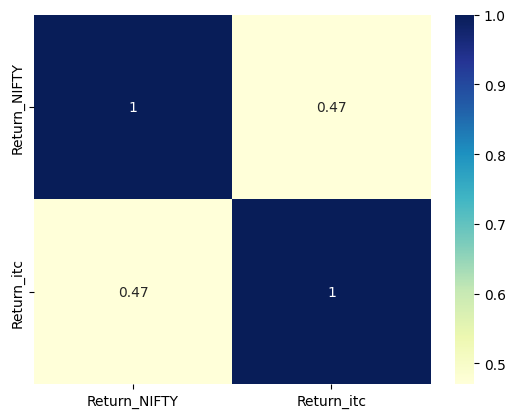

In [ ]:
sns.heatmap(returns.corr(), annot = True, cmap="YlGnBu")
plt.show()

In [ ]:
x = returns['Return_NIFTY']
y = returns['Return_itc']
x_sm = sm.add_constant(x)

**Assumptions of OLS regression**

1) A linear relationship between the dependent and independent variables. The linear regression model is linear in parameters. (*Linearity*)

2) The independent variables are not highly correlated with each other (*no Multicollinearity*)

3) Random sampling of observation and no autocorrelation.

4) Assumption of Normality of Errors

$$
R_i = \alpha_i + \beta_i R_M + \epsilon_i
$$

• Ri = Return of security i

• αi = The return from the asset that is not related to the market’s return. This is “alpha” return from the security

• βi = Beta or the return from the security explained by the market index’s return

• RM = The market index’s return

• εi = Error term for past returns not explained by the regression equation




In [ ]:
#Regression - Market model
model = sm.OLS(y,x_sm)

**OLS estimation or Ordinary Least Square minmizes the sum of squared errors.**

In [ ]:
#Regression result
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Return_itc   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                     16.18
Date:                Mon, 14 Apr 2025   Prob (F-statistic):           0.000171
Time:                        16:40:29   Log-Likelihood:                 87.233
No. Observations:                  59   AIC:                            -170.5
Df Residuals:                      57   BIC:                            -166.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0058      0.008      0.746      0.459      -0.010       0.021
Return_NIFTY     0.7403      0.184      4.023      0.000       0.372       1.109
==============================================================================
Omnibus:                        0.846   Durbin-Watson:                   1.871
Prob(Omnibus):                  0.655   Jarque-Bera (JB):                0.899
Skew:                           0.264   Prob(JB):                        0.638
Kurtosis:                       2.703   Cond. No.                         25.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Beta for ITC = 0.7403**

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 59 entries, 2020-06-01 to 2025-04-01
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Return_NIFTY  59 non-null     float64
 1   Return_itc    59 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB


<Axes: xlabel='Return_NIFTY', ylabel='Return_itc'>

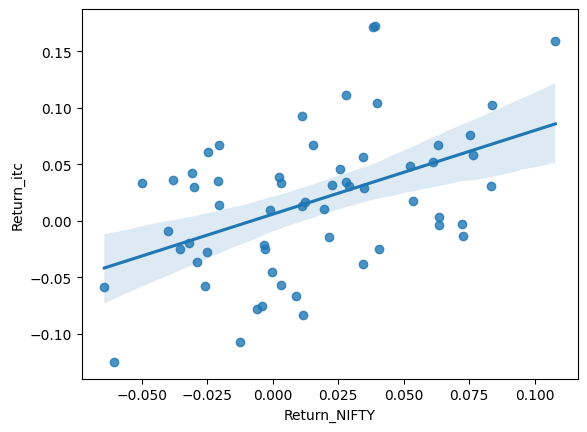

In [ ]:
#Regression - Security Characteristic line
returns.info()
sns.regplot(x = 'Return_NIFTY', y = 'Return_itc', data = returns)

In [ ]:
print('resid', results.resid)

resid Date
2020-06-01   -0.073362
2020-07-01   -0.061836
2020-08-01    0.007791
2020-09-01   -0.103704
2020-10-01   -0.069644
2020-11-01    0.072899
2020-12-01    0.014803
2021-01-01   -0.015095
2021-02-01   -0.049908
2021-03-01    0.078830
2021-04-01   -0.078354
2021-05-01    0.014354
2021-06-01   -0.078696
2021-07-01    0.030706
2021-08-01   -0.036960
2021-09-01    0.084671
2021-10-01   -0.064455
2021-11-01    0.014380
2021-12-01   -0.035920
2022-01-01    0.004607
2022-02-01   -0.002080
2022-03-01    0.137510
2022-04-01    0.044596
2022-05-01    0.058835
2022-06-01    0.064653
2022-07-01    0.034806
2022-08-01    0.024684
2022-09-01    0.058295
2022-10-01    0.003944
2022-11-01   -0.061127
2022-12-01   -0.004745
2023-01-01    0.073381
2023-02-01    0.076181
2023-03-01    0.025344
2023-04-01    0.068751
2023-05-01    0.021013
2023-06-01   -0.002765
2023-07-01    0.003460
2023-08-01   -0.044280
2023-09-01   -0.009817
2023-10-01   -0.021112
2023-11-01   -0.028476
2023-12-01   -0.003766


,0
count,5.900000e+01
mean,5.880419e-19
std,5.563677e-02
min,-1.037044e-01
25%,-4.062008e-02
50%,1.256851e-03
75%,3.275570e-02
max,1.375100e-01


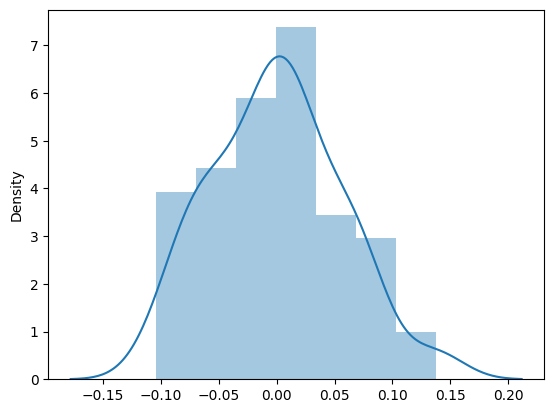

In [ ]:
#Histogram of residuals
sns.distplot(results.resid)
results.resid.describe()

**Cost of Equity using CAPM model**

In [ ]:
risk_free_rate = 0.06994 #from worldgovernmentbonds.com for 10 year Indian govt bond

beta = results.params['Return_NIFTY']

average_monthly_return = nifty_df['Return_NIFTY'].mean()
market_return = (( 1 + average_monthly_return) ** 12 ) - 1  #Annualized Market Return=(1+Average Monthly Return)^12 - 1
##print(market_return)
cost_of_equity_capm = risk_free_rate + beta * (market_return - risk_free_rate)
print(cost_of_equity_capm)

0.16002457825451782


# **2) Calculate the cost of equity capital(Bottom-up approach)**

**hul

In [ ]:
hul_df = yf.download('HINDUNILVR.NS',
                      start='2020-05-01',
                      end='2025-05-01',
                      progress=False,interval ='1mo'
)
hul_df.head()

Price,Close,High,Low,Open,Volume
Ticker,HINDUNILVR.NS,HINDUNILVR.NS,HINDUNILVR.NS,HINDUNILVR.NS,HINDUNILVR.NS
Date,,,,,
2020-05-01,1907.843018,2035.489938,1763.782170,2035.489938,318486932
2020-06-01,2021.580078,2040.080273,1904.782871,1924.210395,77558947
2020-07-01,2063.293701,2194.099467,1984.026114,2038.178356,65932610
2020-08-01,1985.336060,2095.463158,1969.677100,2072.021876,36951713
2020-09-01,1939.297363,2048.768156,1875.349588,2015.903431,49268457


In [ ]:
#Caclulate log returns
hul_df['Return_hul'] = np.log(hul_df['Close']/hul_df['Close'].shift(1))
print(hul_df['Return_hul'])

Date
2020-05-01         NaN
2020-06-01    0.057906
2020-07-01    0.020424
2020-08-01   -0.038515
2020-09-01   -0.023462
2020-10-01    0.001474
2020-11-01    0.038240
2020-12-01    0.113586
2021-01-01   -0.056461
2021-02-01   -0.060005
2021-03-01    0.131424
2021-04-01   -0.032499
2021-05-01   -0.005837
2021-06-01    0.054572
2021-07-01   -0.050251
2021-08-01    0.154855
2021-09-01   -0.008220
2021-10-01   -0.121308
2021-11-01   -0.025973
2021-12-01    0.018215
2022-01-01   -0.037295
2022-02-01   -0.045736
2022-03-01   -0.058514
2022-04-01    0.086993
2022-05-01    0.051623
2022-06-01   -0.053527
2022-07-01    0.176313
2022-08-01    0.008476
2022-09-01    0.013666
2022-10-01   -0.055568
2022-11-01    0.051071
2022-12-01   -0.040334
2023-01-01    0.006112
2023-02-01   -0.046103
2023-03-01    0.039718
2023-04-01   -0.041081
2023-05-01    0.082097
2023-06-01    0.003966
2023-07-01   -0.036672
2023-08-01   -0.022011
2023-09-01   -0.015874
2023-10-01    0.007435
2023-11-01    0.024477
2023-1

In [ ]:
hul_df1 = hul_df.dropna(axis=0)
hul_df1.head()

Price,Close,High,Low,Open,Volume,Return_hul
Ticker,HINDUNILVR.NS,HINDUNILVR.NS,HINDUNILVR.NS,HINDUNILVR.NS,HINDUNILVR.NS,
Date,,,,,,
2020-06-01,2021.580078,2040.080273,1904.782871,1924.210395,77558947,0.057906
2020-07-01,2063.293701,2194.099467,1984.026114,2038.178356,65932610,0.020424
2020-08-01,1985.336060,2095.463158,1969.677100,2072.021876,36951713,-0.038515
2020-09-01,1939.297363,2048.768156,1875.349588,2015.903431,49268457,-0.023462
2020-10-01,1942.157227,2070.802942,1939.062931,1959.691260,47771434,0.001474


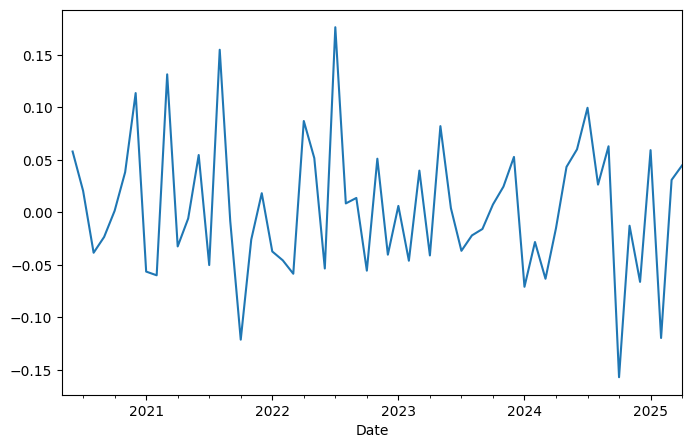

In [ ]:
hul_df['Return_hul'].plot(figsize=(8,5))
plt.show()

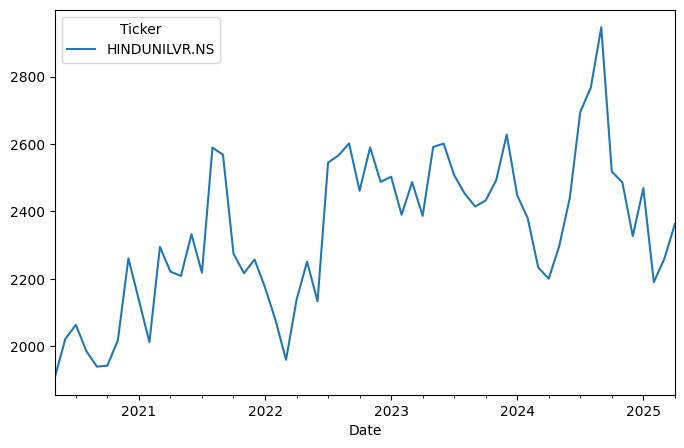

In [ ]:
hul_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
hul_df1_returns = hul_df1['Return_hul']
hul_df1_returns.head()

,Return_hul
Date,
2020-06-01,0.057906
2020-07-01,0.020424
2020-08-01,-0.038515
2020-09-01,-0.023462
2020-10-01,0.001474


In [ ]:
returns = pd.merge(nifty_df1_returns,hul_df1_returns,how='inner',on='Date')
returns.head()
returns.describe()

,Return_NIFTY,Return_hul
count,59.000000,59.000000
mean,0.014717,0.003620
std,0.040045,0.065168
min,-0.064221,-0.157087
25%,-0.020424,-0.040708
50%,0.011765,0.001474
75%,0.039495,0.047883
max,0.107904,0.176313


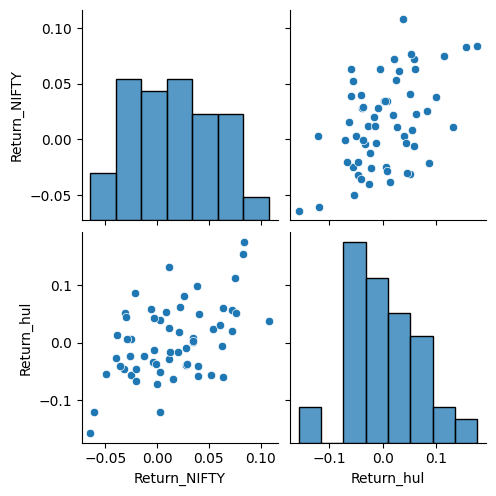

In [ ]:
sns.pairplot(returns)
plt.show()

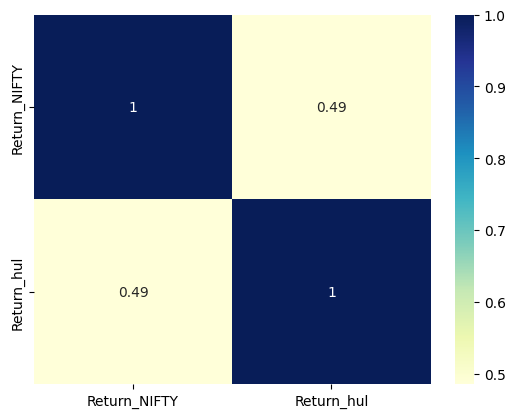

In [ ]:
sns.heatmap(returns.corr(), annot = True, cmap="YlGnBu")
plt.show()

In [ ]:
x = returns['Return_NIFTY']
y = returns['Return_hul']
x_sm = sm.add_constant(x)

In [ ]:
#Regression - Market model
model = sm.OLS(y,x_sm)

In [ ]:
#Regression result
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Return_hul   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     17.57
Date:                Mon, 14 Apr 2025   Prob (F-statistic):           9.73e-05
Time:                        16:40:35   Log-Likelihood:                 85.831
No. Observations:                  59   AIC:                            -167.7
Df Residuals:                      57   BIC:                            -163.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0080      0.008     -1.003      0.320      -0.024       0.008
Return_NIFTY     0.7900      0.188      4.192      0.000       0.413       1.167
==============================================================================
Omnibus:                        1.061   Durbin-Watson:                   2.474
Prob(Omnibus):                  0.588   Jarque-Bera (JB):                1.129
Skew:                           0.265   Prob(JB):                        0.569
Kurtosis:                       2.577   Cond. No.                         25.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Beta for Hindustan Unilever stock = 0.7900**


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 59 entries, 2020-06-01 to 2025-04-01
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Return_NIFTY  59 non-null     float64
 1   Return_hul    59 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB


<Axes: xlabel='Return_NIFTY', ylabel='Return_hul'>

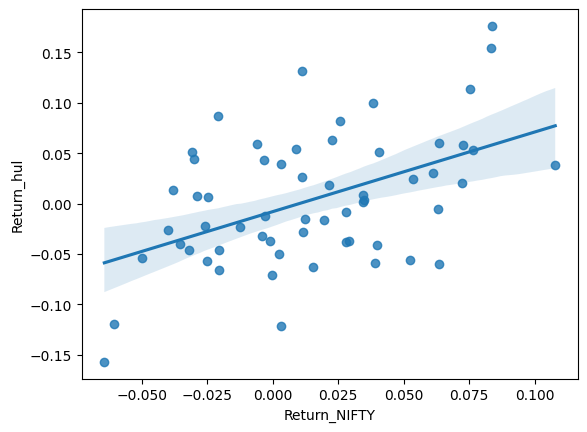

In [ ]:
#Regression - Security Characteristic line
returns.info()
sns.regplot(x = 'Return_NIFTY', y = 'Return_hul', data = returns)

In [ ]:
print('resid', results.resid)

resid Date
2020-06-01    0.008527
2020-07-01   -0.028610
2020-08-01   -0.052602
2020-09-01   -0.005687
2020-10-01   -0.017778
2020-11-01   -0.038999
2020-12-01    0.062188
2021-01-01   -0.028592
2021-02-01   -0.102201
2021-03-01    0.130695
2021-04-01   -0.021280
2021-05-01   -0.047616
2021-06-01    0.055578
2021-07-01   -0.044330
2021-08-01    0.097060
2021-09-01   -0.022310
2021-10-01   -0.115696
2021-11-01    0.013426
2021-12-01    0.009156
2022-01-01   -0.028641
2022-02-01   -0.012455
2022-03-01   -0.081451
2022-04-01    0.111556
2022-05-01    0.083927
2022-06-01   -0.006246
2022-07-01    0.118180
2022-08-01   -0.010718
2022-09-01    0.051821
2022-10-01   -0.088880
2022-11-01    0.027011
2022-12-01   -0.004334
2023-01-01    0.033695
2023-02-01   -0.021910
2023-03-01    0.045182
2023-04-01   -0.064534
2023-05-01    0.069838
2023-06-01   -0.015450
2023-07-01   -0.051581
2023-08-01    0.006250
2023-09-01   -0.023488
2023-10-01    0.038243
2023-11-01   -0.009978
2023-12-01    0.000428


,0
count,5.900000e+01
mean,7.056502e-19
std,5.697390e-02
min,-1.156964e-01
25%,-3.429454e-02
50%,-9.445767e-03
75%,4.171232e-02
max,1.306953e-01


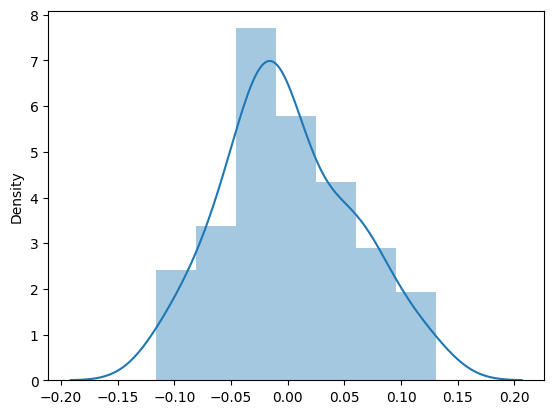

In [ ]:
#Histogram of residuals
sns.distplot(results.resid)
results.resid.describe()

**NESTLEIND**

In [ ]:
nestle_df = yf.download('NESTLEIND.NS',
                      start='2020-05-01',
                      end='2025-05-01',
                      progress=False,interval ='1mo'
)
nestle_df.head()

Price,Close,High,Low,Open,Volume
Ticker,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS
Date,,,,,
2020-05-01,1655.038208,1691.255860,1519.909681,1691.255860,39322590
2020-06-01,1620.471924,1674.682885,1514.583568,1655.038391,34838110
2020-07-01,1564.701904,1682.360904,1556.178634,1629.365141,38357060
2020-08-01,1510.470459,1600.386303,1503.410391,1565.251507,21590020
2020-09-01,1507.544312,1564.020470,1430.015689,1514.774897,26519690


In [ ]:
#Caclulate log returns
nestle_df['Return_nestle'] = np.log(nestle_df['Close']/nestle_df['Close'].shift(1))
print(nestle_df['Return_nestle'])

Date
2020-05-01         NaN
2020-06-01   -0.021107
2020-07-01   -0.035022
2020-08-01   -0.035274
2020-09-01   -0.001939
2020-10-01    0.075183
2020-11-01    0.049426
2020-12-01    0.027637
2021-01-01   -0.075084
2021-02-01   -0.057818
2021-03-01    0.063966
2021-04-01   -0.051152
2021-05-01    0.087006
2021-06-01   -0.003541
2021-07-01    0.003942
2021-08-01    0.095045
2021-09-01   -0.001141
2021-10-01   -0.023171
2021-11-01    0.013890
2021-12-01    0.028472
2022-01-01   -0.061973
2022-02-01   -0.048814
2022-03-01   -0.014769
2022-04-01    0.053204
2022-05-01   -0.030542
2022-06-01   -0.012599
2022-07-01    0.102678
2022-08-01    0.028855
2022-09-01   -0.039987
2022-10-01    0.061708
2022-11-01   -0.002922
2022-12-01   -0.029047
2023-01-01   -0.030463
2023-02-01   -0.018455
2023-03-01    0.053929
2023-04-01    0.099291
2023-05-01    0.000929
2023-06-01    0.054816
2023-07-01   -0.015006
2023-08-01   -0.025457
2023-09-01    0.023398
2023-10-01    0.073968
2023-11-01    0.000056
2023-1

In [ ]:
nestle_df1 = nestle_df.dropna(axis=0)
nestle_df1.head()

Price,Close,High,Low,Open,Volume,Return_nestle
Ticker,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS,NESTLEIND.NS,
Date,,,,,,
2020-06-01,1620.471924,1674.682885,1514.583568,1655.038391,34838110,-0.021107
2020-07-01,1564.701904,1682.360904,1556.178634,1629.365141,38357060,-0.035022
2020-08-01,1510.470459,1600.386303,1503.410391,1565.251507,21590020,-0.035274
2020-09-01,1507.544312,1564.020470,1430.015689,1514.774897,26519690,-0.001939
2020-10-01,1625.255371,1644.044418,1456.058924,1507.577390,29471830,0.075183


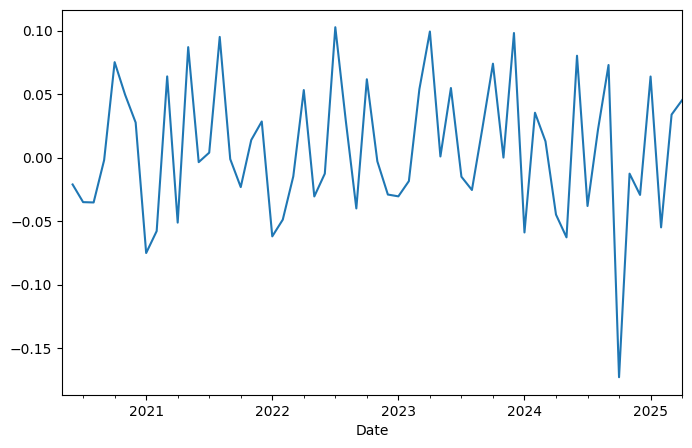

In [ ]:
nestle_df['Return_nestle'].plot(figsize=(8,5))
plt.show()

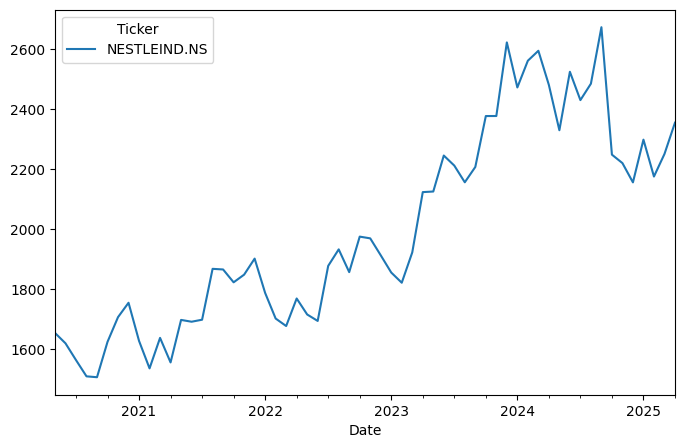

In [ ]:
nestle_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
nestle_df1_returns = nestle_df1['Return_nestle']
nestle_df1_returns.head()


,Return_nestle
Date,
2020-06-01,-0.021107
2020-07-01,-0.035022
2020-08-01,-0.035274
2020-09-01,-0.001939
2020-10-01,0.075183


In [ ]:
returns = pd.merge(nifty_df1_returns,nestle_df1_returns,how='inner',on='Date')
returns.head()
returns.describe()

,Return_NIFTY,Return_nestle
count,59.000000,59.000000
mean,0.014717,0.005978
std,0.040045,0.054269
min,-0.064221,-0.172853
25%,-0.020424,-0.030503
50%,0.011765,-0.001141
75%,0.039495,0.051315
max,0.107904,0.102678


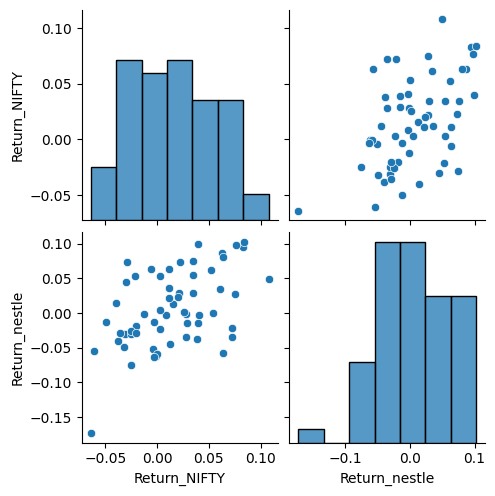

In [ ]:
sns.pairplot(returns)
plt.show()

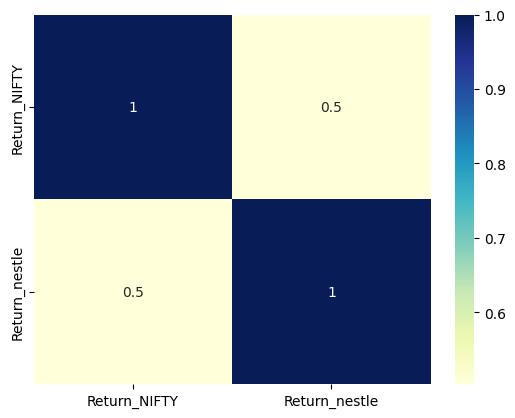

In [ ]:
sns.heatmap(returns.corr(), annot = True, cmap="YlGnBu")
plt.show()

In [ ]:
x = returns['Return_NIFTY']
y = returns['Return_nestle']
x_sm = sm.add_constant(x)

In [ ]:
#Regression - Market model
model = sm.OLS(y,x_sm)

In [ ]:
results = model.fit()
#Regression result
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Return_nestle   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     19.36
Date:                Mon, 14 Apr 2025   Prob (F-statistic):           4.80e-05
Time:                        16:40:38   Log-Likelihood:                 97.328
No. Observations:                  59   AIC:                            -190.7
Df Residuals:                      57   BIC:                            -186.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0041      0.007     -0.619      0.538      -0.017       0.009
Return_NIFTY     0.6824      0.155      4.400      0.000       0.372       0.993
==============================================================================
Omnibus:                        0.450   Durbin-Watson:                   2.153
Prob(Omnibus):                  0.799   Jarque-Bera (JB):                0.554
Skew:                          -0.189   Prob(JB):                        0.758
Kurtosis:                       2.712   Cond. No.                         25.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Beta for NESTLE IND = 0.6824**

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 59 entries, 2020-06-01 to 2025-04-01
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Return_NIFTY   59 non-null     float64
 1   Return_nestle  59 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB


<Axes: xlabel='Return_NIFTY', ylabel='Return_nestle'>

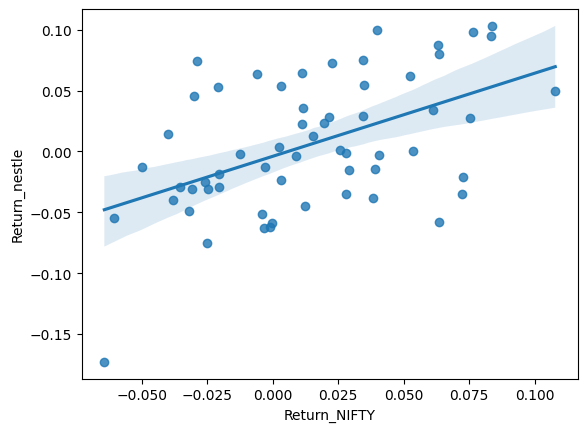

In [ ]:
#Regression - Security Characteristic line
returns.info()
sns.regplot(x = 'Return_NIFTY', y = 'Return_nestle', data = returns)

In [ ]:
print('resid', results.resid)

resid Date
2020-06-01   -0.066609
2020-07-01   -0.080227
2020-08-01   -0.050293
2020-09-01    0.010563
2020-10-01    0.055703
2020-11-01   -0.020141
2020-12-01   -0.019610
2021-01-01   -0.053863
2021-02-01   -0.097116
2021-03-01    0.060484
2021-04-01   -0.044313
2021-05-01    0.048068
2021-06-01   -0.005524
2021-07-01    0.006205
2021-08-01    0.042273
2021-09-01   -0.016163
2021-10-01   -0.021176
2021-11-01    0.045070
2021-12-01    0.017796
2022-01-01   -0.057350
2022-02-01   -0.022919
2022-03-01   -0.037433
2022-04-01    0.071568
2022-05-01   -0.005491
2022-06-01    0.025388
2022-07-01    0.049613
2022-08-01    0.009425
2022-09-01   -0.009882
2022-10-01    0.030083
2022-11-01   -0.026556
2022-12-01   -0.000803
2023-01-01   -0.009489
2023-02-01   -0.000409
2023-03-01    0.055796
2023-04-01    0.076181
2023-05-01   -0.012511
2023-06-01    0.035194
2023-07-01   -0.030735
2023-08-01   -0.003899
2023-09-01    0.013969
2023-10-01    0.097727
2023-11-01   -0.032557
2023-12-01    0.050056


,0
count,5.900000e+01
mean,-3.293034e-18
std,4.688680e-02
min,-1.249660e-01
25%,-2.864536e-02
50%,-3.898707e-03
75%,3.804488e-02
max,9.772692e-02


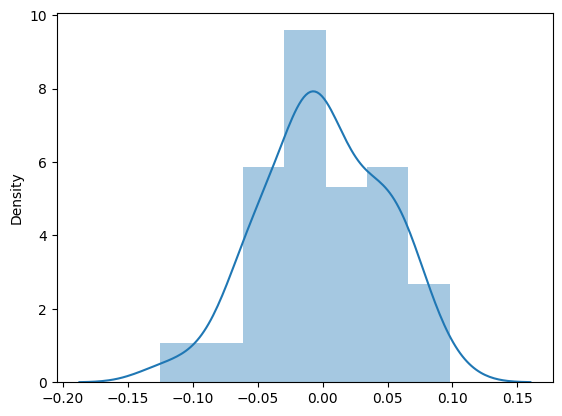

In [ ]:
#Histogram of residuals
sns.distplot(results.resid)
results.resid.describe()

**PGHH  Coroporation India**

In [ ]:
#Download stock prices for the security monthly data last 5 years
pghh_df = yf.download('pghh.NS',
                      start='2020-05-01',
                      end='2025-05-01',
                      progress=False,interval ='1mo'
)
pghh_df.head()

Price,Close,High,Low,Open,Volume
Ticker,PGHH.NS,PGHH.NS,PGHH.NS,PGHH.NS,PGHH.NS
Date,,,,,
2020-05-01,9193.900391,9897.106233,9045.862166,9809.937535,64260
2020-06-01,9433.987305,9515.998539,9082.988333,9286.552581,144476
2020-07-01,9620.034180,10550.176747,9307.927180,9307.927180,170608
2020-08-01,9280.835938,9950.168344,9223.358745,9655.439596,222475
2020-09-01,9243.526367,9525.384640,9006.274773,9381.342239,161366


In [ ]:
#Caclulate log returns
pghh_df['Return_pghh'] = np.log(pghh_df['Close']/pghh_df['Close'].shift(1))
print(pghh_df['Return_pghh'])

Date
2020-05-01         NaN
2020-06-01    0.025779
2020-07-01    0.019529
2020-08-01   -0.035896
2020-09-01   -0.004028
2020-10-01    0.024862
2020-11-01    0.031165
2020-12-01    0.060960
2021-01-01    0.020900
2021-02-01    0.133360
2021-03-01   -0.012081
2021-04-01    0.066333
2021-05-01   -0.031570
2021-06-01    0.024545
2021-07-01   -0.048224
2021-08-01    0.089915
2021-09-01    0.014327
2021-10-01    0.010886
2021-11-01    0.055519
2021-12-01    0.033076
2022-01-01   -0.046693
2022-02-01    0.048716
2022-03-01   -0.065527
2022-04-01   -0.027548
2022-05-01   -0.014722
2022-06-01   -0.033091
2022-07-01    0.080433
2022-08-01   -0.035133
2022-09-01   -0.007430
2022-10-01    0.014425
2022-11-01    0.007126
2022-12-01    0.028909
2023-01-01   -0.025360
2023-02-01   -0.028674
2023-03-01   -0.025970
2023-04-01    0.048681
2023-05-01   -0.034490
2023-06-01    0.057036
2023-07-01    0.095739
2023-08-01    0.012175
2023-09-01    0.117845
2023-10-01   -0.023203
2023-11-01   -0.017297
2023-1

In [ ]:
pghh_df1 = pghh_df.dropna(axis=0)
pghh_df1.head()

Price,Close,High,Low,Open,Volume,Return_pghh
Ticker,PGHH.NS,PGHH.NS,PGHH.NS,PGHH.NS,PGHH.NS,
Date,,,,,,
2020-06-01,9433.987305,9515.998539,9082.988333,9286.552581,144476,0.025779
2020-07-01,9620.034180,10550.176747,9307.927180,9307.927180,170608,0.019529
2020-08-01,9280.835938,9950.168344,9223.358745,9655.439596,222475,-0.035896
2020-09-01,9243.526367,9525.384640,9006.274773,9381.342239,161366,-0.004028
2020-10-01,9476.223633,9720.538486,9089.121491,9232.792709,113201,0.024862


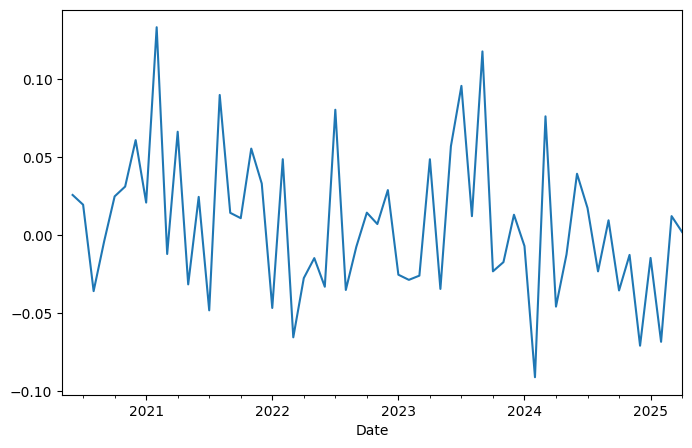

In [ ]:
pghh_df['Return_pghh'].plot(figsize=(8,5))
plt.show()

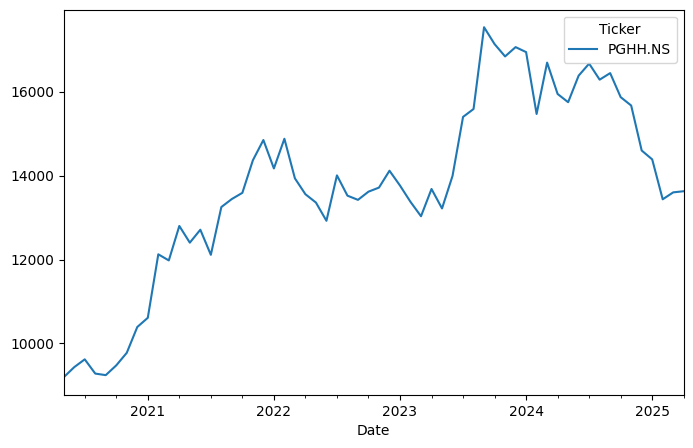

In [ ]:
pghh_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
pghh_df1_returns = pghh_df1['Return_pghh']
pghh_df1_returns.head()


,Return_pghh
Date,
2020-06-01,0.025779
2020-07-01,0.019529
2020-08-01,-0.035896
2020-09-01,-0.004028
2020-10-01,0.024862


In [ ]:
returns = pd.merge(nifty_df1_returns,pghh_df1_returns,how='inner',on='Date')
returns.head()
returns.describe()

,Return_NIFTY,Return_pghh
count,59.000000,59.000000
mean,0.014717,0.006671
std,0.040045,0.046909
min,-0.064221,-0.091116
25%,-0.020424,-0.026759
50%,0.011765,0.007126
75%,0.039495,0.030037
max,0.107904,0.133360


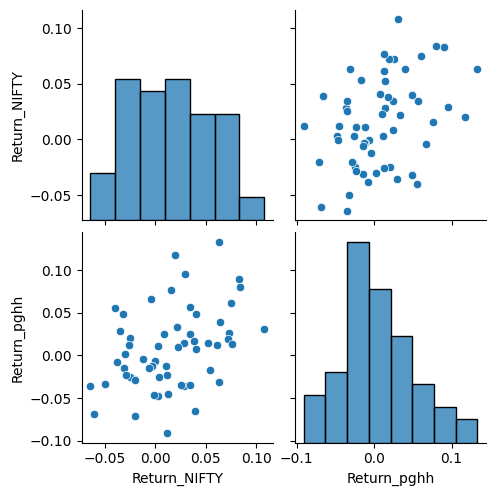

In [ ]:
sns.pairplot(returns)
plt.show()

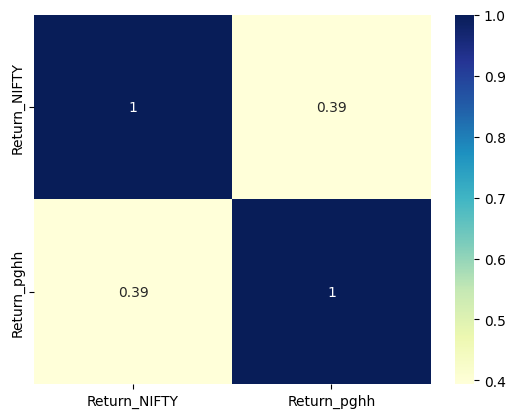

In [ ]:
sns.heatmap(returns.corr(), annot = True, cmap="YlGnBu")
plt.show()

In [ ]:
x = returns['Return_NIFTY']
y = returns['Return_pghh']
x_sm = sm.add_constant(x)

In [ ]:
#Regression - Market model
model = sm.OLS(y,x_sm)

In [ ]:
results = model.fit()
#Regression result
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Return_pghh   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     10.47
Date:                Mon, 14 Apr 2025   Prob (F-statistic):            0.00202
Time:                        16:40:42   Log-Likelihood:                 102.28
No. Observations:                  59   AIC:                            -200.6
Df Residuals:                      57   BIC:                            -196.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0001      0.006     -0.020      0.984      -0.012       0.012
Return_NIFTY     0.4615      0.143      3.236      0.002       0.176       0.747
==============================================================================
Omnibus:                        2.376   Durbin-Watson:                   2.346
Prob(Omnibus):                  0.305   Jarque-Bera (JB):                1.768
Skew:                           0.417   Prob(JB):                        0.413
Kurtosis:                       3.151   Cond. No.                         25.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Beta for pghh  Corporation stock = 0.4615**


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 59 entries, 2020-06-01 to 2025-04-01
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Return_NIFTY  59 non-null     float64
 1   Return_pghh   59 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB


<Axes: xlabel='Return_NIFTY', ylabel='Return_pghh'>

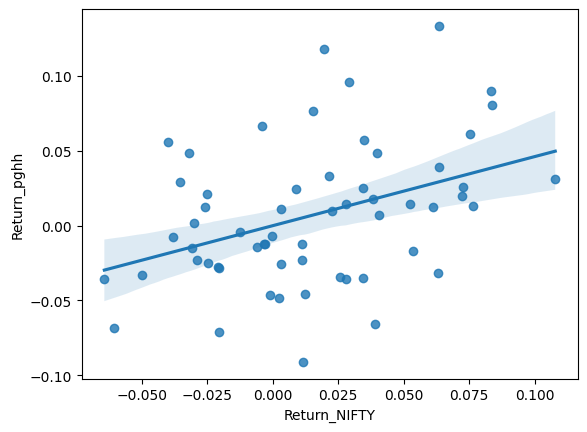

In [ ]:
#Regression - Security Characteristic line
returns.info()
sns.regplot(x = 'Return_NIFTY', y = 'Return_pghh', data = returns)

In [ ]:
print('resid', results.resid)

resid Date
2020-06-01   -0.007626
2020-07-01   -0.013674
2020-08-01   -0.048682
2020-09-01    0.001801
2020-10-01    0.009059
2020-11-01   -0.018516
2020-12-01    0.026376
2021-01-01    0.032626
2021-02-01    0.104152
2021-03-01   -0.017063
2021-04-01    0.068331
2021-05-01   -0.060534
2021-06-01    0.020577
2021-07-01   -0.049321
2021-08-01    0.051594
2021-09-01    0.001539
2021-10-01    0.009608
2021-11-01    0.073981
2021-12-01    0.023228
2022-01-01   -0.046194
2022-02-01    0.063603
2022-03-01   -0.083484
2022-04-01   -0.017754
2022-05-01   -0.000405
2022-06-01   -0.010025
2022-07-01    0.041914
2022-08-01   -0.050902
2022-09-01    0.010305
2022-10-01   -0.009592
2022-11-01   -0.011486
2022-12-01    0.045385
2023-01-01   -0.013801
2023-02-01   -0.019096
2023-03-01   -0.027334
2023-04-01    0.030423
2023-05-01   -0.046208
2023-06-01    0.041137
2023-07-01    0.082473
2023-08-01    0.024130
2023-09-01    0.108840
2023-10-01   -0.009760
2023-11-01   -0.041983
2023-12-01   -0.022043


,0
count,5.900000e+01
mean,-5.409985e-18
std,4.311455e-02
min,-9.642444e-02
25%,-2.056940e-02
50%,-7.625822e-03
75%,2.367884e-02
max,1.088399e-01


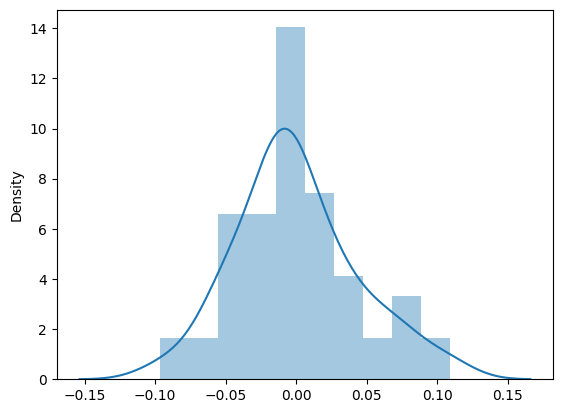

In [ ]:
#Histogram of residuals
sns.distplot(results.resid)
results.resid.describe()

**DABUR**

In [ ]:
dabur_df = yf.download('DABUR.NS',
                      start='2020-05-01',
                      end='2025-05-01',
                      progress=False,interval ='1mo'
)
dabur_df.head()

Price,Close,High,Low,Open,Volume
Ticker,DABUR.NS,DABUR.NS,DABUR.NS,DABUR.NS,DABUR.NS
Date,,,,,
2020-05-01,446.196411,468.054224,402.911199,468.054224,76121252
2020-06-01,445.718140,456.192666,412.285681,449.592274,83853216
2020-07-01,491.251282,492.638333,442.848393,450.453181,83695701
2020-08-01,453.992554,505.073884,450.453199,492.494842,67850952
2020-09-01,489.938110,493.920590,454.527840,459.086073,61045428


In [ ]:
#Caclulate log returns
dabur_df['Return_dabur'] = np.log(dabur_df['Close']/dabur_df['Close'].shift(1))
print(dabur_df['Return_dabur'])

Date
2020-05-01         NaN
2020-06-01   -0.001072
2020-07-01    0.097269
2020-08-01   -0.078875
2020-09-01    0.076198
2020-10-01    0.001761
2020-11-01   -0.023042
2020-12-01    0.069592
2021-01-01   -0.037103
2021-02-01   -0.022504
2021-03-01    0.071706
2021-04-01   -0.004543
2021-05-01    0.004451
2021-06-01    0.051039
2021-07-01    0.054655
2021-08-01    0.039137
2021-09-01   -0.007186
2021-10-01   -0.051886
2021-11-01    0.015414
2021-12-01   -0.021224
2022-01-01   -0.077582
2022-02-01    0.048369
2022-03-01   -0.049394
2022-04-01    0.037519
2022-05-01   -0.070123
2022-06-01   -0.045429
2022-07-01    0.163597
2022-08-01    0.003992
2022-09-01   -0.018417
2022-10-01   -0.032371
2022-11-01    0.058895
2022-12-01   -0.042343
2023-01-01   -0.006612
2023-02-01   -0.046140
2023-03-01    0.022832
2023-04-01   -0.022269
2023-05-01    0.041355
2023-06-01    0.031110
2023-07-01    0.004615
2023-08-01   -0.035196
2023-09-01   -0.002716
2023-10-01   -0.042024
2023-11-01    0.017152
2023-1

In [ ]:
dabur_df1 = dabur_df.dropna(axis=0)
dabur_df1.head()

Price,Close,High,Low,Open,Volume,Return_dabur
Ticker,DABUR.NS,DABUR.NS,DABUR.NS,DABUR.NS,DABUR.NS,
Date,,,,,,
2020-06-01,445.718140,456.192666,412.285681,449.592274,83853216,-0.001072
2020-07-01,491.251282,492.638333,442.848393,450.453181,83695701,0.097269
2020-08-01,453.992554,505.073884,450.453199,492.494842,67850952,-0.078875
2020-09-01,489.938110,493.920590,454.527840,459.086073,61045428,0.076198
2020-10-01,490.801819,513.401050,484.708174,494.928208,72282120,0.001761


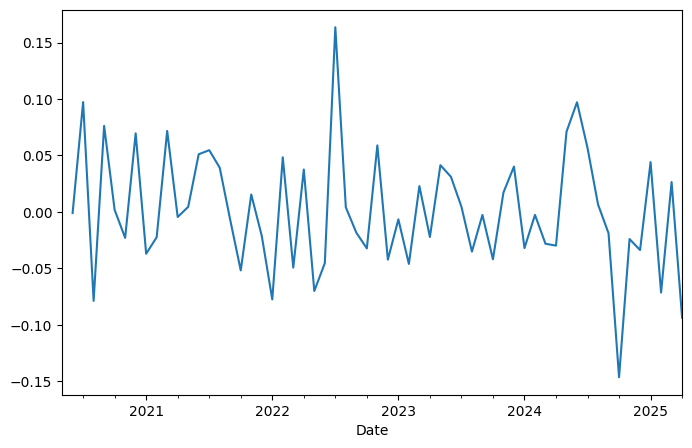

In [ ]:
dabur_df['Return_dabur'].plot(figsize=(8,5))
plt.show()

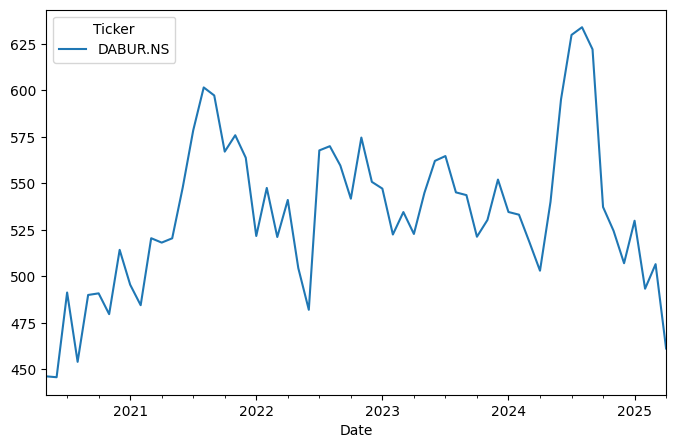

In [ ]:
dabur_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
dabur_df1_returns = dabur_df1['Return_dabur']
dabur_df1_returns.head()

,Return_dabur
Date,
2020-06-01,-0.001072
2020-07-01,0.097269
2020-08-01,-0.078875
2020-09-01,0.076198
2020-10-01,0.001761


In [ ]:
returns = pd.merge(nifty_df1_returns,dabur_df1_returns,how='inner',on='Date')
returns.head()
returns.describe()

,Return_NIFTY,Return_dabur
count,59.000000,59.000000
mean,0.014717,0.000559
std,0.040045,0.053889
min,-0.064221,-0.146502
25%,-0.020424,-0.033093
50%,0.011765,-0.002716
75%,0.039495,0.039632
max,0.107904,0.163597


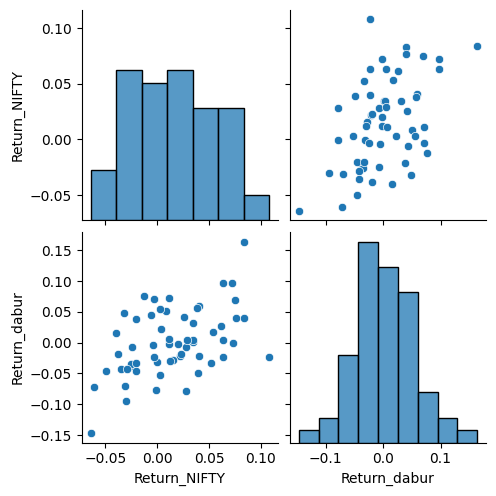

In [ ]:
sns.pairplot(returns)
plt.show()

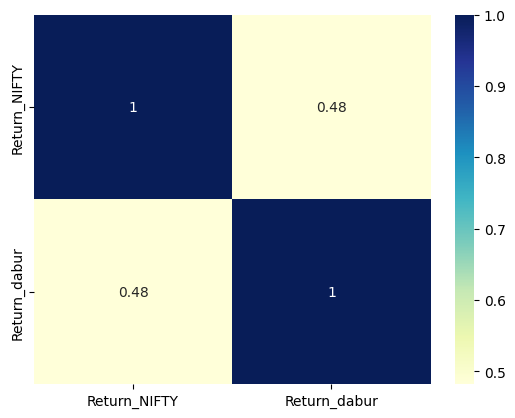

In [ ]:
sns.heatmap(returns.corr(), annot = True, cmap="YlGnBu")
plt.show()

In [ ]:
x = returns['Return_NIFTY']
y = returns['Return_dabur']
x_sm = sm.add_constant(x)

In [ ]:
#Regression - Market model
model = sm.OLS(y,x_sm)

In [ ]:
#Regression result
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Return_dabur   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     17.23
Date:                Mon, 14 Apr 2025   Prob (F-statistic):           0.000112
Time:                        16:40:48   Log-Likelihood:                 96.908
No. Observations:                  59   AIC:                            -189.8
Df Residuals:                      57   BIC:                            -185.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0090      0.007     -1.358      0.180      -0.022       0.004
Return_NIFTY     0.6484      0.156      4.151      0.000       0.336       0.961
==============================================================================
Omnibus:                        0.977   Durbin-Watson:                   2.536
Prob(Omnibus):                  0.614   Jarque-Bera (JB):                1.020
Skew:                           0.283   Prob(JB):                        0.600
Kurtosis:                       2.694   Cond. No.                         25.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Beta for dabur
 stock = 0.6484**


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 59 entries, 2020-06-01 to 2025-04-01
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Return_NIFTY  59 non-null     float64
 1   Return_dabur  59 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB


<Axes: xlabel='Return_NIFTY', ylabel='Return_dabur'>

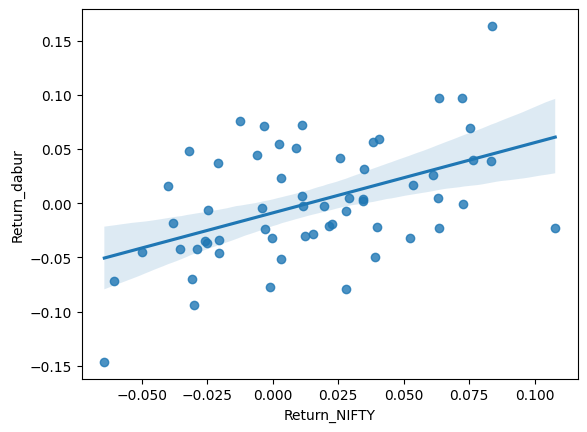

In [ ]:
#Regression - Security Characteristic line
returns.info()
sns.regplot(x = 'Return_NIFTY', y = 'Return_dabur', data = returns)

In [ ]:
print('resid', results.resid)

resid Date
2020-06-01   -0.039186
2020-07-01    0.059438
2020-08-01   -0.088024
2020-09-01    0.093200
2020-10-01   -0.011626
2020-11-01   -0.084021
2020-12-01    0.029820
2021-01-01   -0.011818
2021-02-01   -0.054722
2021-03-01    0.073519
2021-04-01    0.007076
2021-05-01   -0.027426
2021-06-01    0.054277
2021-07-01    0.061927
2021-08-01   -0.005884
2021-09-01   -0.016338
2021-10-01   -0.044869
2021-11-01    0.050162
2021-12-01   -0.026246
2022-01-01   -0.068067
2022-02-01    0.078095
2022-03-01   -0.065807
2022-04-01    0.060091
2022-05-01   -0.041198
2022-06-01   -0.004213
2022-07-01    0.118298
2022-08-01   -0.009348
2022-09-01    0.015309
2022-10-01   -0.057299
2022-11-01    0.041561
2022-12-01   -0.010385
2023-01-01    0.018439
2023-02-01   -0.023872
2023-03-01    0.029728
2023-04-01   -0.039105
2023-05-01    0.033706
2023-06-01    0.017587
2023-07-01   -0.005209
2023-08-01   -0.009590
2023-09-01   -0.006553
2023-10-01   -0.014327
2023-11-01   -0.008714
2023-12-01   -0.000419


,0
count,5.900000e+01
mean,-3.528251e-18
std,4.722178e-02
min,-9.587929e-02
25%,-2.683602e-02
50%,-8.713591e-03
75%,3.176315e-02
max,1.182983e-01


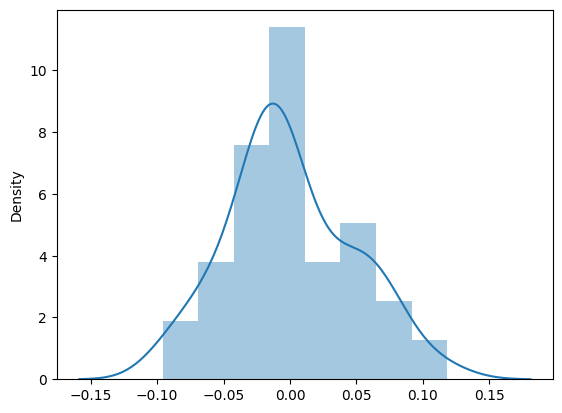

In [ ]:
#Histogram of residuals
sns.distplot(results.resid)
results.resid.describe()

**GODREJCP**

In [ ]:
#Download stock prices for the security monthly data last 5 years
gcp_df = yf.download('GODREJCP.NS',
                      start='2020-05-01',
                      end='2025-05-01',
                      progress=False,interval ='1mo'
)
gcp_df.head()

Price,Close,High,Low,Open,Volume
Ticker,GODREJCP.NS,GODREJCP.NS,GODREJCP.NS,GODREJCP.NS,GODREJCP.NS
Date,,,,,
2020-05-01,618.678711,624.682007,472.501465,530.240281,46747869
2020-06-01,674.318787,681.054189,577.143876,620.045323,44477549
2020-07-01,675.343689,704.481558,647.670092,678.418560,27754398
2020-08-01,635.761108,699.600803,631.563711,679.394656,24739496
2020-09-01,707.653992,719.367693,625.706878,637.420579,34054491


In [ ]:
#Caclulate log returns
gcp_df['Return_GODREJ'] = np.log(gcp_df['Close']/gcp_df['Close'].shift(1))
print(gcp_df['Return_GODREJ'])

Date
2020-05-01         NaN
2020-06-01    0.086117
2020-07-01    0.001519
2020-08-01   -0.060399
2020-09-01    0.107132
2020-10-01   -0.086617
2020-11-01    0.051237
2020-12-01    0.056130
2021-01-01    0.006062
2021-02-01   -0.081454
2021-03-01    0.061105
2021-04-01   -0.053340
2021-05-01    0.213688
2021-06-01    0.015868
2021-07-01    0.126700
2021-08-01    0.106949
2021-09-01   -0.065212
2021-10-01   -0.073779
2021-11-01   -0.035700
2021-12-01    0.047856
2022-01-01   -0.086284
2022-02-01   -0.145585
2022-03-01   -0.027258
2022-04-01    0.045900
2022-05-01   -0.019945
2022-06-01   -0.012332
2022-07-01    0.119549
2022-08-01    0.079344
2022-09-01   -0.015044
2022-10-01   -0.093357
2022-11-01    0.060986
2022-12-01   -0.008431
2023-01-01    0.043872
2023-02-01    0.010945
2023-03-01    0.047433
2023-04-01   -0.064693
2023-05-01    0.153773
2023-06-01    0.021175
2023-07-01   -0.042568
2023-08-01   -0.030182
2023-09-01   -0.013572
2023-10-01    0.000252
2023-11-01    0.016350
2023-1

In [ ]:
gcp_df1 = gcp_df.dropna(axis=0)
gcp_df1.head()

Price,Close,High,Low,Open,Volume,Return_GODREJ
Ticker,GODREJCP.NS,GODREJCP.NS,GODREJCP.NS,GODREJCP.NS,GODREJCP.NS,
Date,,,,,,
2020-06-01,674.318787,681.054189,577.143876,620.045323,44477549,0.086117
2020-07-01,675.343689,704.481558,647.670092,678.418560,27754398,0.001519
2020-08-01,635.761108,699.600803,631.563711,679.394656,24739496,-0.060399
2020-09-01,707.653992,719.367693,625.706878,637.420579,34054491,0.107132
2020-10-01,648.939026,743.820016,645.229699,711.607338,31984852,-0.086617


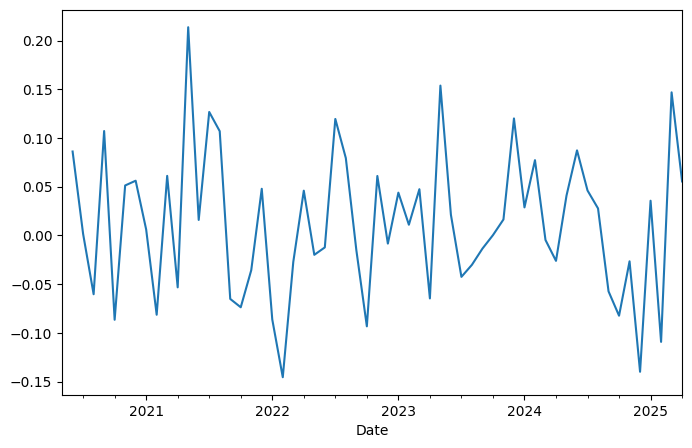

In [ ]:
gcp_df['Return_GODREJ'].plot(figsize=(8,5))
plt.show()

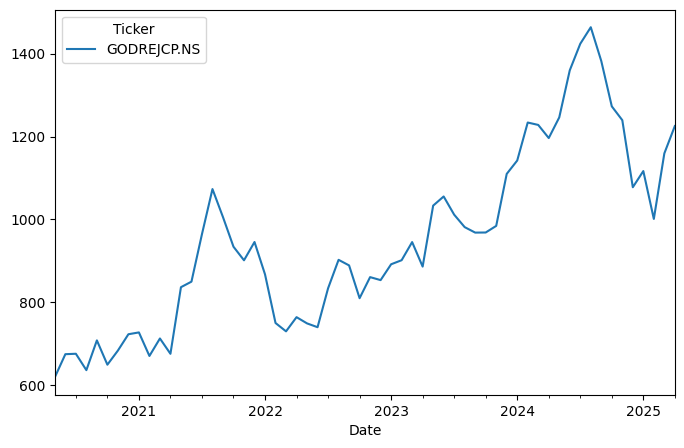

In [ ]:
gcp_df['Close'].plot(figsize=(8,5))
plt.show()

In [ ]:
gcp_df1_returns = gcp_df1['Return_GODREJ']
gcp_df1_returns.head()


,Return_GODREJ
Date,
2020-06-01,0.086117
2020-07-01,0.001519
2020-08-01,-0.060399
2020-09-01,0.107132
2020-10-01,-0.086617


In [ ]:
returns = pd.merge(nifty_df1_returns,gcp_df1_returns,how='inner',on='Date')
returns.head()
returns.describe()

,Return_NIFTY,Return_GODREJ
count,59.000000,59.000000
mean,0.014717,0.011582
std,0.040045,0.075575
min,-0.064221,-0.145585
25%,-0.020424,-0.039134
50%,0.011765,0.010945
75%,0.039495,0.055771
max,0.107904,0.213688


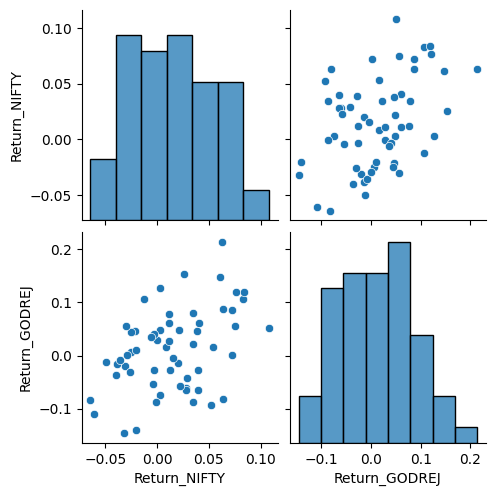

In [ ]:
sns.pairplot(returns)
plt.show()

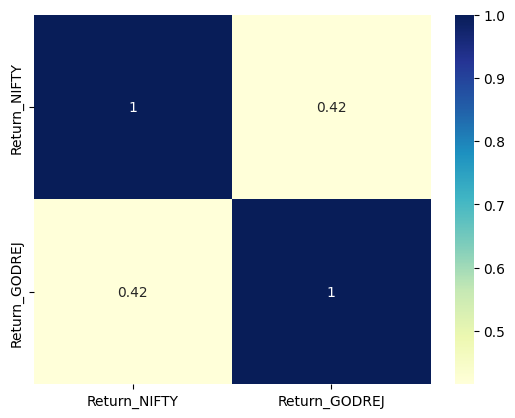

In [ ]:
sns.heatmap(returns.corr(), annot = True, cmap="YlGnBu")
plt.show()

In [ ]:
x = returns['Return_NIFTY']
y = returns['Return_GODREJ']
x_sm = sm.add_constant(x)

In [ ]:
#Regression - Market model
model = sm.OLS(y,x_sm)

In [ ]:
results = model.fit()
#Regression result
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Return_GODREJ   R-squared:                       0.173
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     11.90
Date:                Mon, 14 Apr 2025   Prob (F-statistic):            0.00106
Time:                        16:40:50   Log-Likelihood:                 74.756
No. Observations:                  59   AIC:                            -145.5
Df Residuals:                      57   BIC:                            -141.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         3.922e-05      0.010      0.004      0.997      -0.019       0.019
Return_NIFTY     0.7843      0.227      3.450      0.001       0.329       1.240
==============================================================================
Omnibus:                        0.183   Durbin-Watson:                   2.174
Prob(Omnibus):                  0.913   Jarque-Bera (JB):                0.382
Skew:                          -0.042   Prob(JB):                        0.826
Kurtosis:                       2.615   Cond. No.                         25.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Beta for GODREJ CONSUMER PRODUCTS stock = 0.7843**


In [ ]:
#Step 1: Take comparable companies
tickers = ['HINDUNILVR.NS', 'DABUR.NS', 'NESTLEIND.NS', 'PGHH.NS','GODREJCP.NS']

# Step 2: Beta equity
beta_levered = [0.7900, 0.6484, 0.6824 , 0.4615 ,0.7843]

# Step 3: Take market value of D/E
debt_to_equity = [0.00, 0.12,0.01 ,0.00, 0.25]

tax_rate = [24.9434,21.4611, 24.511, 26.0989 ,26.8328]

data = {
    'Ticker': tickers,
    'Beta Levered': beta_levered,
    'D/E': debt_to_equity,
    'Tax': tax_rate
}

company_info = pd.DataFrame(data)
company_info



,Ticker,Beta Levered,D/E,Tax
0,HINDUNILVR.NS,0.7900,0.00,24.9434
1,DABUR.NS,0.6484,0.12,21.4611
2,NESTLEIND.NS,0.6824,0.01,24.5110
3,PGHH.NS,0.4615,0.00,26.0989
4,GODREJCP.NS,0.7843,0.25,26.8328


In [ ]:
beta_unlevered = []
for i in range(len(tickers)):
    unlevered_beta = beta_levered[i] / (1 + (1 - tax_rate[i] / 100) * debt_to_equity[i])
    beta_unlevered.append(unlevered_beta)

# Calculate the mean of unlevered betas
mean_betas = np.mean(beta_unlevered)
print(f'Average of Unlevered Betas = {mean_betas}')

data = {
    'Ticker': tickers,
    'Beta Unlevered': beta_unlevered,
    'D/E': debt_to_equity,
    'Tax(%)': tax_rate
}
company_info = pd.DataFrame(data)
company_info

Average of Unlevered Betas = 0.6368724888222322


,Ticker,Beta Unlevered,D/E,Tax(%)
0,HINDUNILVR.NS,0.790000,0.00,24.9434
1,DABUR.NS,0.592554,0.12,21.4611
2,NESTLEIND.NS,0.677287,0.01,24.5110
3,PGHH.NS,0.461500,0.00,26.0989
4,GODREJCP.NS,0.663021,0.25,26.8328


In [ ]:
# Step 5: Market D/E for itc
avg_unlev_beta = 0.6368724888222322
nestle_debt_to_equity = 0.0014
nestle_tax_rate = 22.59

# Step 6: Relever the beta for the
nestle_relevered_beta = avg_unlev_beta * (1 + (1 - nestle_tax_rate/100) * nestle_debt_to_equity)
print(f'Relevered beta of itc INDIA Ltd = {nestle_relevered_beta}')

# Calculating Cost of Equity Capital
risk_free_rate = 0.06994 #from worldgovernmentbonds.com for 10 year Indian govt bond
market_return = 0.16354264739934687
cost_of_equity = risk_free_rate + nestle_relevered_beta * (market_return - risk_free_rate)
print(f'Cost of Equity Capital(Bottom Up Approach): {cost_of_equity}')


Relevered beta of itc INDIA Ltd = 0.6375626930132685
Cost of Equity Capital(Bottom Up Approach): 0.12961755594909902


#3) Calculate Cost of Debt

In [ ]:
#Calculate EBIT/Interest expense
EBIT_DATA = [179827500000, 207798300000, 259583200000, 271858400000]  # 2021–2024
interest_expense_data = [445800000, 393600000, 432000000, 459600000]  # 2021–2024

EBIT = np.mean(EBIT_DATA)
interest_expense = np.mean(interest_expense_data)

interest_coverage = EBIT/interest_expense
print(f'\nInterest Coverage Ratio = {interest_coverage}')

# Get Credit Default Spread
credit_default_spread = 0.0075  # since rating is AAA  => spread = 0.75%

risk_free_rate = 0.06994

# Calculate cost of debt
cost_of_debt = risk_free_rate + credit_default_spread
print(f'Cost of Debt: {cost_of_debt}')


Interest Coverage Ratio = 530.9459272097054
Cost of Debt: 0.07744000000000001


# 4) Calculate the cost of capital for the firm (WACC Calculation)

In [ ]:
# Calculate market value of equity
debt_to_equity = 0.00

risk_free_rate = 0.06994
cost_of_debt = risk_free_rate + 0.0075
itc_tax_rate = 17.45
debt_to_valuation = debt_to_equity/(debt_to_equity+1)
equity_to_valuation = 1 - debt_to_valuation

# Top Down Approach
cost_of_equity_top = 0.15999337968257948
WACC_top = cost_of_debt * (1 - itc_tax_rate/100) * debt_to_valuation + cost_of_equity_top * equity_to_valuation
print(f'WACC (Top Down Approach) = {WACC_top}')

# Bottom Up Approach
cost_of_equity_bottom = 0.12957406347226058
WACC_bottom = cost_of_debt * (1 - itc_tax_rate/100) * debt_to_valuation + cost_of_equity_bottom * equity_to_valuation
print(f'WACC (Bottom Up Approach) = {WACC_bottom}')

WACC (Top Down Approach) = 0.15999337968257948
WACC (Bottom Up Approach) = 0.12957406347226058
